# Exercise 2

In [77]:
from functions import RandomnessTests
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(42)
import time
import tracemalloc

In [89]:
from importlib import reload
import functions

reload(functions)

from functions import RandomnessTests

## Part 1


==================== geo p=0.05 ====================


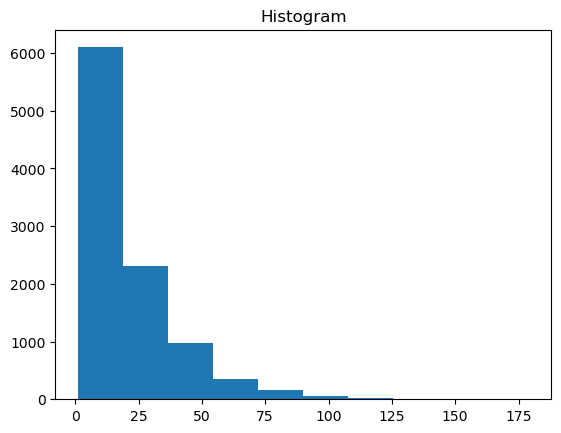

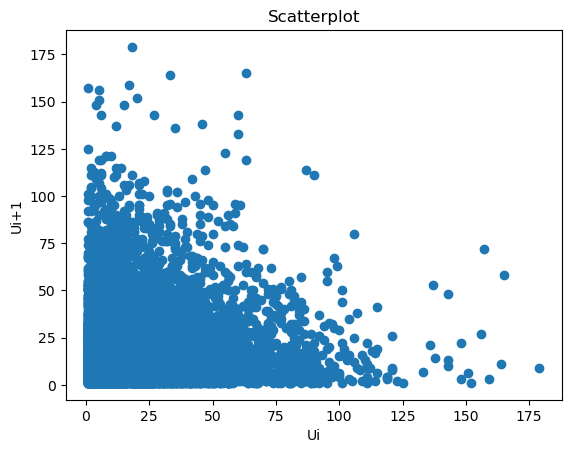


Chi-square
T = 33638.8780
df = 9

KS test
Kolmogorov-Smirnov test statistic: 178.0
Adjusted Kolmogorov-Smirnov test statistic: 17821.5558

Wald-Wolfowitz
Number of runs: 4991
Z-score: -0.034127509305921636

Knuth run test
Number of runs: 4859
Z-score: 28.965884660549627

Up-Down run test
Number of runs: 6602
Z-score: -1.5259372653626553

Correlation tests
lag=1   corr=395.604060 z=179315.746912
lag=2   corr=400.643729 z=181601.525618
lag=5   corr=398.960780 z=180838.211992
lag=10  corr=401.151552 z=181831.852393

==================== geo p=0.3 ====================


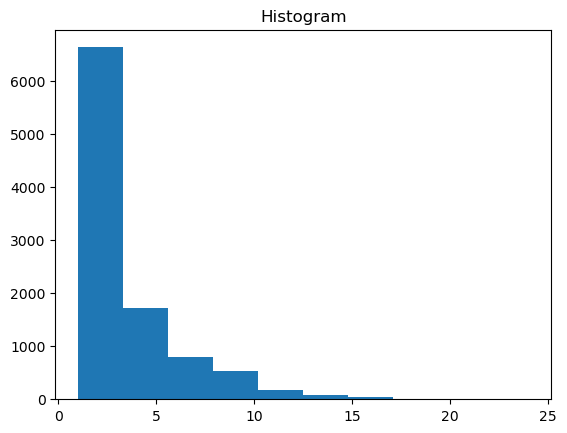

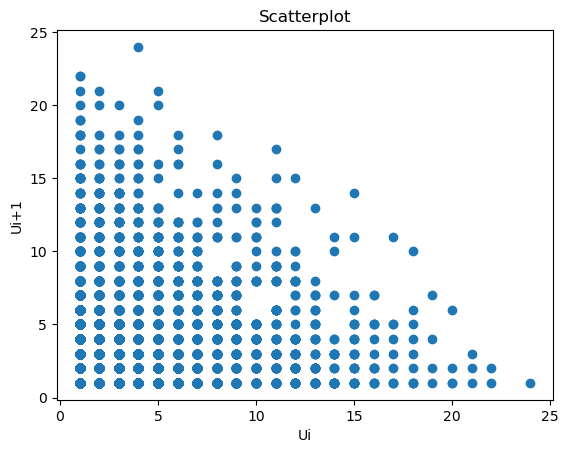


Chi-square
T = 37922.2060
df = 9

KS test
Kolmogorov-Smirnov test statistic: 23.0
Adjusted Kolmogorov-Smirnov test statistic: 2302.7853

Wald-Wolfowitz
Number of runs: 5019
Z-score: 0.44179782957872865

Knuth run test
Number of runs: 4151
Z-score: 1399.131200993097

Up-Down run test
Number of runs: 6440
Z-score: -5.368452866224074

Correlation tests
lag=1   corr=10.990299 z=4871.341755
lag=2   corr=10.982597 z=4867.848225
lag=5   corr=11.172386 z=4953.928730
lag=10  corr=11.086987 z=4915.195291

==================== geo p=0.7 ====================


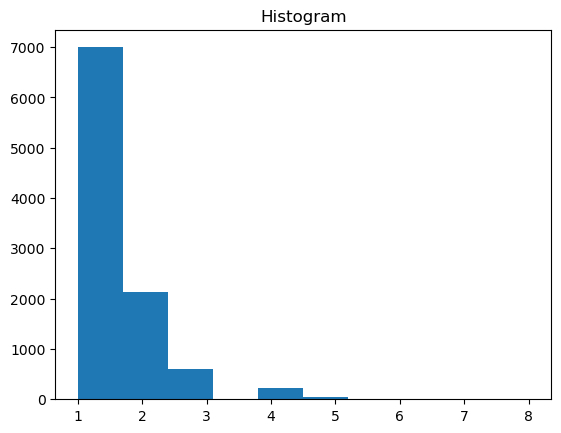

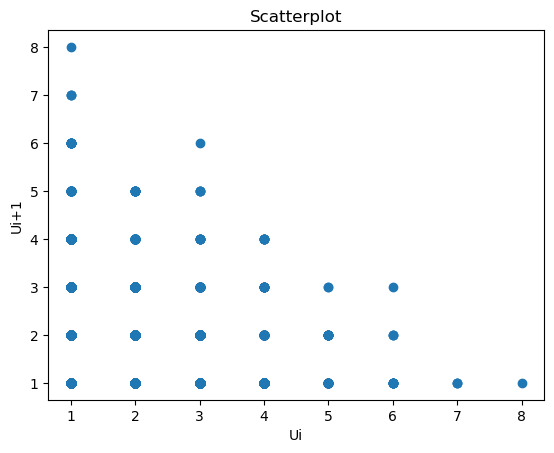


Chi-square
T = 43868.7900
df = 9

KS test
Kolmogorov-Smirnov test statistic: 7.0
Adjusted Kolmogorov-Smirnov test statistic: 700.8477

Wald-Wolfowitz
Number of runs: 4177
Z-score: -0.6421715835802835

Knuth run test
Number of runs: 2294
Z-score: 733560.0608397294

Up-Down run test
Number of runs: 4282
Z-score: -56.55455574683483

Correlation tests
lag=1   corr=2.026003 z=805.519064
lag=2   corr=2.028306 z=806.563634
lag=5   corr=2.007504 z=797.128775
lag=10  corr=2.016416 z=801.171180


In [44]:
p1, p2, p3 = 0.05, 0.3, 0.7
X005 = np.random.geometric(p1, size=10000)
X03 = np.random.geometric(p2, size=10000)
X07 = np.random.geometric(p3, size=10000)

results = RandomnessTests.compare_datasets(
    [X005, X03, X07],
    labels=["geo p=0.05", "geo p=0.3", "geo p=0.7"],
    correlation_lags=[1, 2, 5, 10]
)

## Part 2

### direct (crude) method
Mest grundlæggende måde at generere en diskret stokastisk variabel på. 
Ideen er at man bruger et uniformt tal og finder hvilket interval U falder i, baseret på den kumulative fordelingsfunktion.

In [45]:
xi = [1, 2, 3, 4, 5, 6]
PXxi = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

In [46]:
def direct(x, p, n_samples):
    u = random.random()
    P = []
    current = 0
    for pi in p:
        current += pi
        P.append(current)

    samples = []
    for _ in range(n_samples):
        u = random.random()  # U ~ Uniform(0,1)

        # Linear search for at finde det første P[i], der er større end eller lig med u
        for i in range(len(P)):
            if u <= P[i]:
                samples.append(x[i])
                break

    return samples


In [47]:
direct_samples = direct(xi, PXxi, 10000)

### rejection method
Alternativ måde til at generere en diskret stokastisk variabel på. 
Ideen er at man foreslår et udfald og accepterer det kun med en vis sansynlighed. Hvis det afvises, prøver man igen.

In [ ]:
def simple_rejection(x, p, n_samples):
    c = max(p)
    samples = []
    k = len(x)

    while len(samples) < n_samples:
        I = int(np.floor(k*random.random())) # nul indeksering i python så inge plus en

        if random.random() <= p[I]/c: 
            samples.append(x[I])
    return samples

In [56]:
simple_rejection_samples = simple_rejection(xi, PXxi, 10000)

### alias method
Alias metoden er en hurtig måde at generere fra en vilkårlig diskret fordeling.
Ideen er at man omdanner en vilkårlig diskret fordeling til k "buckets" hver med en primlr værdi og en alias-værdi. Under samplingen kræver det så kun et opslag og en sammenligning for at finde det korrekte udfald.

In [57]:
def alias_method(p, x, n_samples):

    k = len(p)

    # Konstruer lookup tabeller
    q = [pi * k for pi in p]
    prob = [0] * k
    alias = [0] * k

    small = []
    large = []

    for i in range(k):
        if q[i] < 1:
            small.append(i)
        else:
            large.append(i)

    # Fyld buckets
    while small and large:
        s = small.pop()
        l = large.pop()

        prob[s] = q[s]
        alias[s] = l

        q[l] = q[l] - (1 - q[s])

        if q[l] < 1:
            small.append(l)
        else:
            large.append(l)

    # Resten sættes til 1
    for i in small + large:
        prob[i] = 1
        alias[i] = i

    # --- 2. Sampling ---
    samples = []
    for _ in range(n_samples):
        i = int(random.random() * k)  # bucket index
        if random.random() < prob[i]:
            samples.append(x[i])
        else:
            samples.append(x[alias[i]])

    return samples


In [58]:
alias_samples = alias_method(PXxi, xi, 10000)

## Part 3

### Ease of implementation
Hvor let er det at implementere?

### Computational efficency
Hvor lang tid tager det?

In [75]:
def measure_time(func, *args, repeats=10, **kwargs):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()
        func(*args, **kwargs)
        end = time.perf_counter()
        times.append(end - start)

    return {
        "mean_time": np.mean(times),
        "std_time": np.std(times)
    }

In [76]:
print(f'direct_method: {measure_time(direct, xi, PXxi, 10000)["mean_time"]:.4f} +- {measure_time(direct, xi, PXxi, 10000)["std_time"]:.4f} seconds')
print(f'rejection_method: {measure_time(simple_rejection, xi, PXxi, 10000)["mean_time"]:.4f} +- {measure_time(simple_rejection, xi, PXxi, 10000)["std_time"]:.4f} seconds')
print(f'alias_method: {measure_time(alias_method, PXxi, xi, 10000)["mean_time"]:.4f} +- {measure_time(alias_method, PXxi, xi, 10000)["std_time"]:.4f} seconds')

direct_method: 0.0026 +- 0.0002 seconds
rejection_method: 0.0237 +- 0.0020 seconds
alias_method: 0.0020 +- 0.0002 seconds


### Memory requirements
Hvor meget hukommelse kræver det?

In [78]:
def measure_memory(func, *args, **kwargs):
    tracemalloc.start()

    result = func(*args, **kwargs)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "current_memory": current,
        "peak_memory": peak,
        "result": result
    }

In [81]:
print(f'direct_method memory: {measure_memory(direct, xi, PXxi, 10000)["peak_memory"] / 1024:.2f} KB')
print(f'rejection_method memory: {measure_memory(simple_rejection, xi, PXxi, 10000)["peak_memory"] / 1024:.2f} KB')
print(f'alias_method memory: {measure_memory(alias_method, PXxi, xi, 10000)["peak_memory"] / 1024:.2f} KB')

direct_method memory: 84.03 KB
rejection_method memory: 84.23 KB
alias_method memory: 83.41 KB


### Accuracy of the generated distributions
Hvor godt matcher de genererede fordelinger den ønskede fordeling?

In [90]:
def measure_accuracy(data):
    results = RandomnessTests.analyze(
        data,
        histogram=False,
        scatter=False,
        chi_square=True,
        ks=True,
        wald_wolf=True,
        knuth=True,
        up_down=True,
        correlation=False
    )

    return results

In [91]:
print(f'direct method accuracy: {measure_accuracy(direct_samples)}')
print(f'rejection method accuracy: {measure_accuracy(simple_rejection_samples)}')
print(f'alias method accuracy: {measure_accuracy(alias_samples)}')

Kolmogorov-Smirnov test statistic: 5.3121
Adjusted Kolmogorov-Smirnov test statistic: 531.85329531
Number of runs: 4342
Z-score: 1.1032387571442732
Number of runs: 3988
Z-score: 1923.6536922656687
Number of runs: 6359
Z-score: -7.289710666654784
direct method accuracy: {'chi_square': (11262.194, 9), 'ks': (5.3121, 531.85329531), 'wald_wolf': (4342, 1.1032387571442732), 'knuth': (3988, 1923.6536922656687), 'up_down': (6359, -7.289710666654784)}
Kolmogorov-Smirnov test statistic: 5.3121
Adjusted Kolmogorov-Smirnov test statistic: 531.85329531
Number of runs: 4297
Z-score: 0.055347298213060225
Number of runs: 3931
Z-score: 2452.643748839119
Number of runs: 6280
Z-score: -9.163530002877328
rejection method accuracy: {'chi_square': (11008.196, 9), 'ks': (5.3121, 531.85329531), 'wald_wolf': (4297, 0.055347298213060225), 'knuth': (3931, 2452.643748839119), 'up_down': (6280, -9.163530002877328)}
Kolmogorov-Smirnov test statistic: 5.3088
Adjusted Kolmogorov-Smirnov test statistic: 531.522895679

## Sammenligning

In [92]:
def evaluate_generator(name, func, *args, **kwargs):

    print(f"\n===== Evaluating {name} =====")

    # Time
    t = measure_time(func, *args, **kwargs)
    print("Time:", t)

    # Memory
    m = measure_memory(func, *args, **kwargs)
    data = m["result"]
    print("Peak memory:", m["peak_memory"])

    # Accuracy
    acc = measure_accuracy(data)
    print("Accuracy tests done")

    return {
        "time": t,
        "memory": m,
        "accuracy": acc
    }

In [93]:
gens = [
    ("Direct Method", direct, {"x": xi, "p": PXxi, "n_samples": 10000}),
    ("Rejection Method", simple_rejection, {"x": xi, "p": PXxi, "n_samples": 10000}),
    ("Alias Method", alias_method, {"p": PXxi, "x": xi, "n_samples": 10000}),
]

all_results = {}

for name, func, kwargs in gens:
    all_results[name] = evaluate_generator(
        name,
        func,
        **kwargs
    )


===== Evaluating Direct Method =====
Time: {'mean_time': 0.0024955899993074127, 'std_time': 0.0009680918811514349}
Peak memory: 85344
Kolmogorov-Smirnov test statistic: 5.313
Adjusted Kolmogorov-Smirnov test statistic: 531.9434043
Number of runs: 4276
Z-score: -0.5898003130835047
Number of runs: 3900
Z-score: 2482.97744397692
Number of runs: 6302
Z-score: -8.641706896587506
Accuracy tests done

===== Evaluating Rejection Method =====
Time: {'mean_time': 0.018194086600487935, 'std_time': 0.0015262507803811816}
Peak memory: 85692
Kolmogorov-Smirnov test statistic: 5.3036
Adjusted Kolmogorov-Smirnov test statistic: 531.00226596
Number of runs: 4236
Z-score: 0.15780895295019934
Number of runs: 3964
Z-score: 2360.662041719708
Number of runs: 6308
Z-score: -8.49939150396301
Accuracy tests done

===== Evaluating Alias Method =====
Time: {'mean_time': 0.001799528000265127, 'std_time': 4.605697013967875e-05}
Peak memory: 85416
Kolmogorov-Smirnov test statistic: 5.3062000000000005
Adjusted Kolm

In [94]:
for name, func, kwargs in gens:
    result = evaluate_generator(name, func, **kwargs)

    print("\n", name)
    print(result.keys())
    print(result.get("accuracy"))

    all_results[name] = result


===== Evaluating Direct Method =====
Time: {'mean_time': 0.002798553699904005, 'std_time': 0.00031286513448097866}
Peak memory: 85691
Kolmogorov-Smirnov test statistic: 5.3124
Adjusted Kolmogorov-Smirnov test statistic: 531.88333164
Number of runs: 4315
Z-score: 0.42184618079371067
Number of runs: 3922
Z-score: 3281.435968615417
Number of runs: 6273
Z-score: -9.329564627605908
Accuracy tests done

 Direct Method
dict_keys(['time', 'memory', 'accuracy'])
{'chi_square': (11275.624, 9), 'ks': (5.3124, 531.88333164), 'wald_wolf': (4315, 0.42184618079371067), 'knuth': (3922, 3281.435968615417), 'up_down': (6273, -9.329564627605908)}

===== Evaluating Rejection Method =====
Time: {'mean_time': 0.021033166199049446, 'std_time': 0.0014754037042209968}
Peak memory: 85786
Kolmogorov-Smirnov test statistic: 5.3152
Adjusted Kolmogorov-Smirnov test statistic: 532.16367072
Number of runs: 4332
Z-score: 0.33079370386986817
Number of runs: 3915
Z-score: 3119.90004833322
Number of runs: 6287
Z-score: 

### Plots

In [118]:
def z_normalize(values):
    # Positivt = over gennemsnittet, Negativt = under gennemsnittet
    values = np.array(values, dtype=float)
    if np.std(values) == 0:
        return values
    return (values - np.mean(values)) / np.std(values)

def plot_all_results(all_results, normalize=True):
    names = list(all_results.keys())

    # time
    times = [
        all_results[name]["time"]["mean_time"]
        for name in names
    ]

    plt.figure()
    plt.bar(names, z_normalize(times) if normalize else times)
    plt.title("Computational Efficiency (Time)")
    plt.ylabel("Seconds")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # memory
    memory = [
        all_results[name]["memory"]["peak_memory"] / 1024
        for name in names
    ]

    plt.figure()
    plt.bar(names, z_normalize(memory) if normalize else memory)
    plt.title("Memory Usage (Peak)")
    plt.ylabel("KB")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # accuracy
    ks_values = []

    for name in names:
        ks = all_results[name]["accuracy"]["ks"][0]
        ks_values.append(ks)

    plt.figure()
    plt.bar(names, z_normalize(ks_values) if normalize else ks_values)
    plt.title("Distribution Accuracy (KS statistic)")
    plt.ylabel("KS Dn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    chi2_values = []

    for name in names:
        chi2 = all_results[name]["accuracy"]["chi_square"][0]
        chi2_values.append(chi2)

    plt.figure()
    plt.bar(names, z_normalize(chi2_values) if normalize else chi2_values)
    plt.title("Distribution Accuracy (Chi-Square)")
    plt.ylabel("Chi-Square Statistic")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

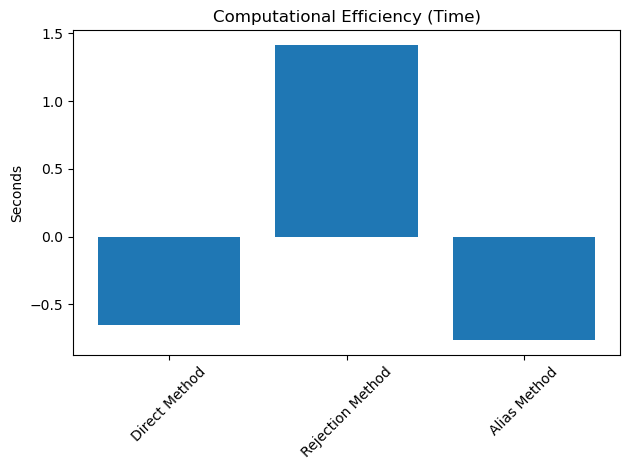

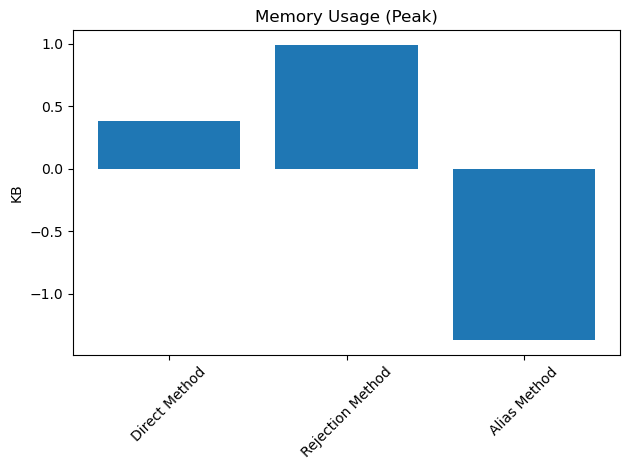

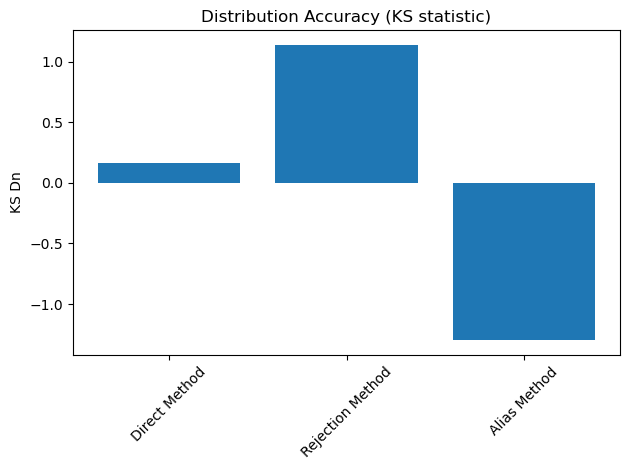

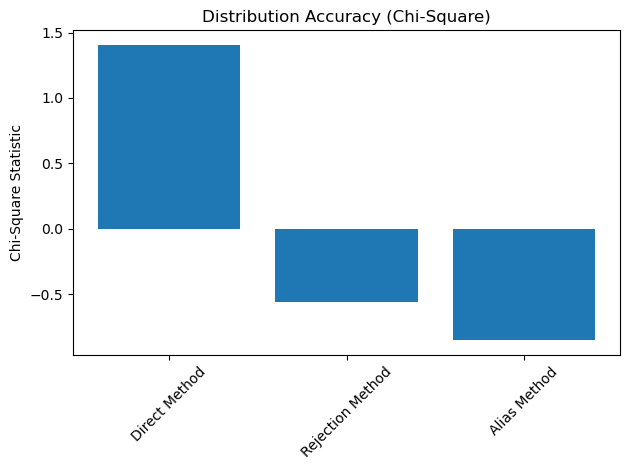

In [119]:
plot_all_results(all_results)

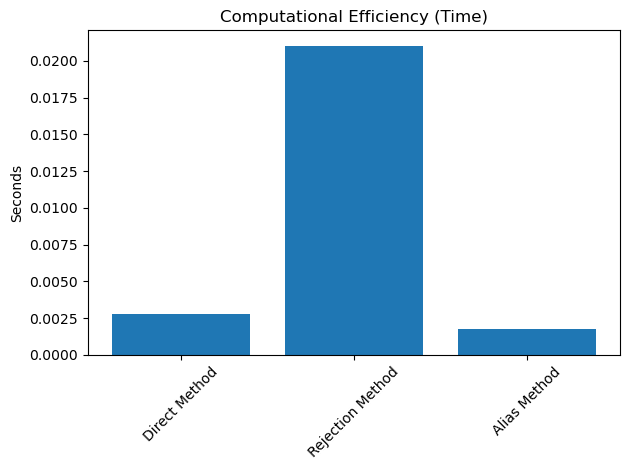

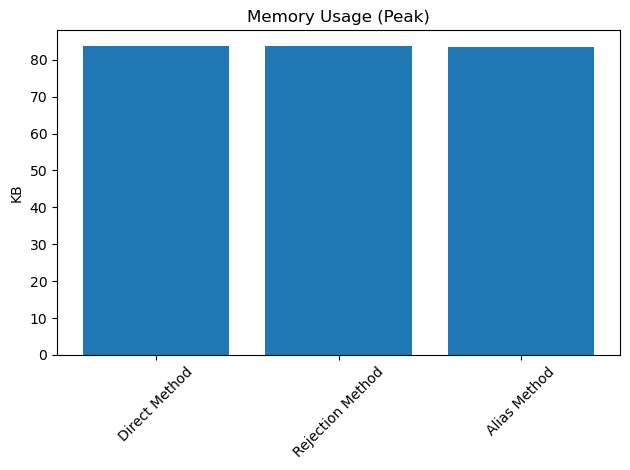

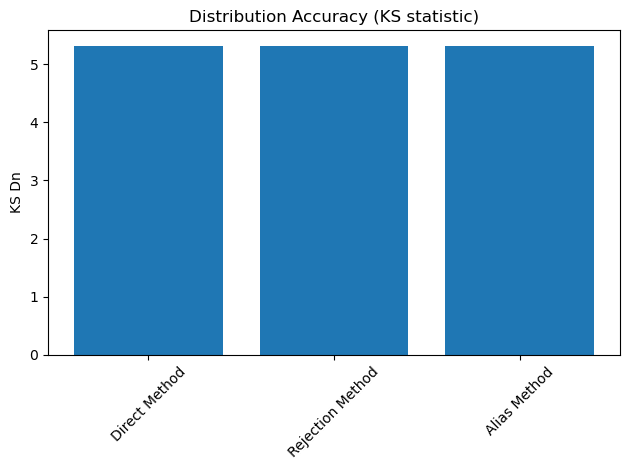

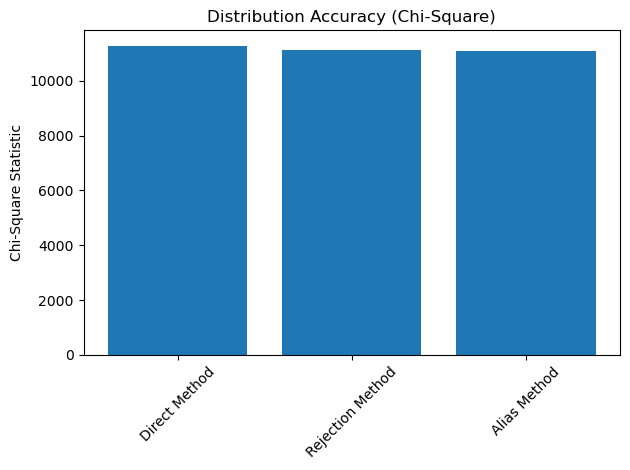

In [120]:
plot_all_results(all_results, normalize=False)

## Part 4